# Clamped Plate Study

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyck as ck

The following plate formulations are compared against a manufactured clamped-plate benchmark across a wide range of slenderness ratios $L/h$:

| Formulation | DOFs / node | Expected failure |
|---|---|---|
| **KL-1p** (Kirchhoff–Love) | $w$ | Low slenderness — shear neglected |
| **RM-3p** (Reissner–Mindlin, standard) | $w, \varphi_x, \varphi_y$ | High slenderness — shear locking |
| **RM-displ-3p** (split displacement) | $w_b, w_{s1}, w_{s2}$ | Displacement-only RM split under clamped Lagrange BCs |
| **RM-displ-1p** (Reissner–Mindlin, rotation-free) | $w_b$ | Accurate across the full range |

In [2]:
FORMULATIONS = {
    "KL-1p": ck.PlateKirchhoffLove1p,
    "RM-3p": ck.PlateReissnerMindlin3p,
    "RM-displ-3p": ck.PlateReissnerMindlinDispl3p,
    "RM-1p": ck.PlateReissnerMindlin1p,
}

## **Manufactured Clamped Benchmark**

The benchmark uses the analytical displacement field

$$\begin{aligned}
w(x,y) = &\frac{1}{3} x^3 (x-1)^3 y^3 (y-1)^3 \\
& -\frac{2t^2}{5(1-\nu)} \Big[ y^3 (y-1)^3 x (x-1) (5x^2-5x+1)
+ x^3 (x-1)^3 y (y-1)(5y^2 - 5y + 1) \Big],
\end{aligned}$$

together with the manufactured transverse load

$$\begin{aligned}
f = \frac{E}{12(1-\nu^2)} \Big[
&12\,y(y-1)\,(5x^2 - 5x + 1)\,
\Big(2y^2 (y-1)^2 + x(x-1)(5y^2 - 5y + 1)\Big) \\
+ &12x(x-1)(5y^2-5y+1)\Big(2x^2(x-1)^2 + y(y-1)(5x^2-5x+1)\Big)
\Big].
\end{aligned}$$

In the physical plate problem solved here, the load density is assembled as
$q(x,y,t) = t^3 f(x,y)$ so that it is consistent with the bending-stiffness scaling
$D = Et^3/[12(1-\nu^2)]$.

In [3]:
def exact_load(x, y, h, E, nu):
    pref = E * h ** 3 / (12.0 * (1.0 - nu ** 2))
    term_y = 12.0 * y * (y - 1.0) * (5.0 * x ** 2 - 5.0 * x + 1.0)
    term_y *= (
        2.0 * y ** 2 * (y - 1.0) ** 2
        + x * (x - 1.0) * (5.0 * y ** 2 - 5.0 * y + 1.0)
    )

    term_x = 12.0 * x * (x - 1.0) * (5.0 * y ** 2 - 5.0 * y + 1.0)
    term_x *= (
        2.0 * x ** 2 * (x - 1.0) ** 2
        + y * (y - 1.0) * (5.0 * x ** 2 - 5.0 * x + 1.0)
    )
    return pref * (term_x + term_y)


def exact_displacement(x, y, h, nu):
    bend = (x ** 3 * (x - 1.0) ** 3 * y ** 3 * (y - 1.0) ** 3) / 3.0
    shear_x = y ** 3 * (y - 1.0) ** 3 * x * (x - 1.0) * (5.0 * x ** 2 - 5.0 * x + 1.0)
    shear_y = x ** 3 * (x - 1.0) ** 3 * y * (y - 1.0) * (5.0 * y ** 2 - 5.0 * y + 1.0)
    corr = 2.0 * h ** 2 * (shear_x + shear_y) / (5.0 * (1.0 - nu))
    return bend - corr


def exact_max_displacement(h, nu):
    return abs(exact_displacement(0.5, 0.5, h, nu))


def exact_strain_energy(h, E, nu, nq=80):
    xi, wi = np.polynomial.legendre.leggauss(nq)
    x = 0.5 * (xi + 1.0)
    w = 0.5 * wi
    xx, yy = np.meshgrid(x, x, indexing="xy")
    ww = np.outer(w, w)
    f = exact_load(xx, yy, h, E, nu)
    disp = exact_displacement(xx, yy, h, nu)
    return 0.5 * np.sum(ww * f * disp)


def load_fn_factory(h, E, nu):
    def load_fn(pts):
        return exact_load(pts[:, 0], pts[:, 1], h, E, nu)

    return load_fn


def numerical_max_displacement(surf, element, u, n_eval=81):
    """Recover the maximum displacement from the solution vector."""
    grid = np.linspace(0.0, 1.0, n_eval)
    uu, vv = np.meshgrid(grid, grid, indexing="xy")
    pts_param = np.column_stack([uu.ravel(), vv.ravel()])
    shape = ck.eval_shape_at(surf, pts_param, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    w = Nw @ u
    return np.max(np.abs(w))


def physical_solution(surf, element, u):
    n_phys = surf.num_control_pts * element._cpp_object.num_node_dofs()
    return np.asarray(u)[:n_phys]


def evaluate_displacement(surf, element, u, pts_param):
    """Evaluate the transverse displacement at parametric points."""
    shape = ck.eval_shape_at(surf, pts_param, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    return np.asarray(Nw @ u).reshape(-1)


def sample_boundary(side: str, npts: int):
    s = np.linspace(0.0, 1.0, npts)
    if side == "u0":
        return np.column_stack([np.zeros_like(s), s]), s, "y"
    if side == "u1":
        return np.column_stack([np.ones_like(s), s]), s, "y"
    if side == "v0":
        return np.column_stack([s, np.zeros_like(s)]), s, "x"
    if side == "v1":
        return np.column_stack([s, np.ones_like(s)]), s, "x"
    raise ValueError(f"Unknown boundary side: {side}")


def sample_centerline(npts: int):
    s = np.linspace(0.0, 1.0, npts)
    return np.column_stack([s, 0.5 * np.ones_like(s)]), s, "x"

## **Lagrange Multipliers**

The clamped boundary conditions are enforced weakly with Lagrange multipliers by imposing
zero transverse displacement and zero boundary-normal rotation:

$$
w = 0, \qquad \varphi_n = 0 \qquad \text{on } \Gamma.
$$

After discretization, the resulting saddle-point system reads

$$
\begin{bmatrix}
\mathbf{K} & \mathbf{C}^T \\
\mathbf{C} & \mathbf{0}
\end{bmatrix}
\begin{bmatrix}
\mathbf{u} \\
\boldsymbol{\lambda}
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{f} \\
\mathbf{0}
\end{bmatrix}.
$$

In [4]:
def apply_clamped_lagrange(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
):
    """Apply clamped boundary conditions via Lagrange multipliers."""
    for side in ("u0", "u1", "v0", "v1"):
        bd = patch.boundary(side)
        cond = ck.LagrangeMultiplierCondition(
            bd, element, quadrature,
            w_bar=0.0,
            phi_n_bar=0.0,
        )
        problem.add_condition(cond)

## Comparison

In [ ]:
# Plate geometry
L, W = 1.0, 1.0
slenderness = np.logspace(np.log10(5.0), 6.0, 15)

# Plate material parameters
E = 1.0e7
nu = 0.3

# Numerical parameters
p = 4
n = 12


def solve_plate_case(
    L: float, W: float, h: float, formulation: str
) -> dict:
    # Constitutive law
    mat = ck.PlaneStress2d(E, nu, h)

    # Patch geometry
    bu = ck.create_clamped_uniform(p, n)
    bv = ck.create_clamped_uniform(p, n)
    patch = ck.create_rectangle(bu, bv, L, W)

    # Quadrature rules for surface and boundary integration
    gauss2d = ck.create_gauss_from_patch(patch)
    gauss1d = ck.GaussLegendre(p + 1, dim=1)

    # Load function
    load_fn = load_fn_factory(h, E, nu)

    # Element formulation
    element_cls = FORMULATIONS[formulation]
    element = element_cls(mat)

    # Define linear elastic problem
    prob = ck.create_linear_elastic_problem([patch], element, gauss2d)

    # Apply loads and boundary conditions, assemble system
    prob.add_condition(ck.create_function_load_condition(patch, load_fn, gauss2d))
    apply_clamped_lagrange(prob, patch, element, gauss1d)
    K, f = prob.assemble()

    # Solve
    u_full = ck.solve(K, f)
    u = physical_solution(patch, element, u_full)

    # Postprocessing: max displacement and strain energy
    w = numerical_max_displacement(patch, element, u)
    U = 0.5 * f[:u.size] @ u

    return {
        "patch": patch,
        "element": element,
        "u": u,
        "w": w,
        "U": U,
    }

In [7]:
s_history = []
U_exact_history = []
w_exact_history = []
U_history = {name: [] for name in FORMULATIONS}
w_history = {name: [] for name in FORMULATIONS}

print("Clamped manufactured plate with Lagrange-multiplier BCs")
print(
    f"{'L/h':>10} | "
    f"{'KL-1p U%':>8} | {'KL-1p w%':>8} | "
    f"{'RM-3p U%':>8} | {'RM-3p w%':>8} | "
    f"{'RM-d-3p U%':>9} | {'RM-d-3p w%':>9} | "
    f"{'RM-d-1p U%':>8} | {'RM-d-1p w%':>8}"
)
print("-" * 104)

for slenderness_value in slenderness:
    # Analytical benchmarks
    h = L / slenderness_value
    U_exact = exact_strain_energy(h, E, nu)
    w_exact = exact_max_displacement(h, nu)

    # Store results
    s_history.append(slenderness_value)
    U_exact_history.append(U_exact)
    w_exact_history.append(w_exact)
    error_history = {}

    # Solve for each formulation
    for formulation in FORMULATIONS:
        results = solve_plate_case(L, W, h, formulation)

        U_history[formulation].append(results["U"])
        w_history[formulation].append(results["w"])

        error_history[formulation] = (
            abs(results["U"] - U_exact) / U_exact * 100.0,
            abs(results["w"] - w_exact) / w_exact * 100.0,
        )

    print(
        f"{slenderness_value:10.1f} | "
        f"{error_history['KL-1p'][0]:7.2f}% | {error_history['KL-1p'][1]:7.2f}% | "
        f"{error_history['RM-3p'][0]:7.2f}% | {error_history['RM-3p'][1]:7.2f}% | "
        f"{error_history['RM-displ-3p'][0]:9.2f}% | {error_history['RM-displ-3p'][1]:9.2f}% | "
        f"{error_history['RM-1p'][0]:8.2f}% | {error_history['RM-1p'][1]:8.2f}%"
    )

Clamped manufactured plate with Lagrange-multiplier BCs
       L/h | KL-1p U% | KL-1p w% | RM-3p U% | RM-3p w% | RM-d-3p U% | RM-d-3p w% | RM-d-1p U% | RM-d-1p w%
--------------------------------------------------------------------------------------------------------
       5.0 |   53.58% |   35.43% |    0.00% |    0.01% |      0.00% |      0.01% |     0.11% |     0.06%
      12.0 |   16.80% |    8.76% |    0.00% |    0.01% |      0.00% |      0.01% |     0.04% |     0.02%
      28.6 |    3.41% |    1.66% |    0.01% |    0.00% |      0.01% |      0.01% |     0.01% |     0.01%
      68.4 |    0.62% |    0.30% |    0.03% |    0.02% |      0.01% |      0.01% |     0.01% |     0.01%
     163.5 |    0.11% |    0.06% |    0.17% |    0.06% |      0.01% |      0.01% |     0.01% |     0.01%
     391.0 |    0.02% |    0.02% |    0.89% |    0.09% |      0.01% |      0.01% |     0.01% |     0.01%
     935.1 |    0.01% |    0.01% |    4.33% |    1.80% |      0.01% |      0.01% |     0.01% |     0.0

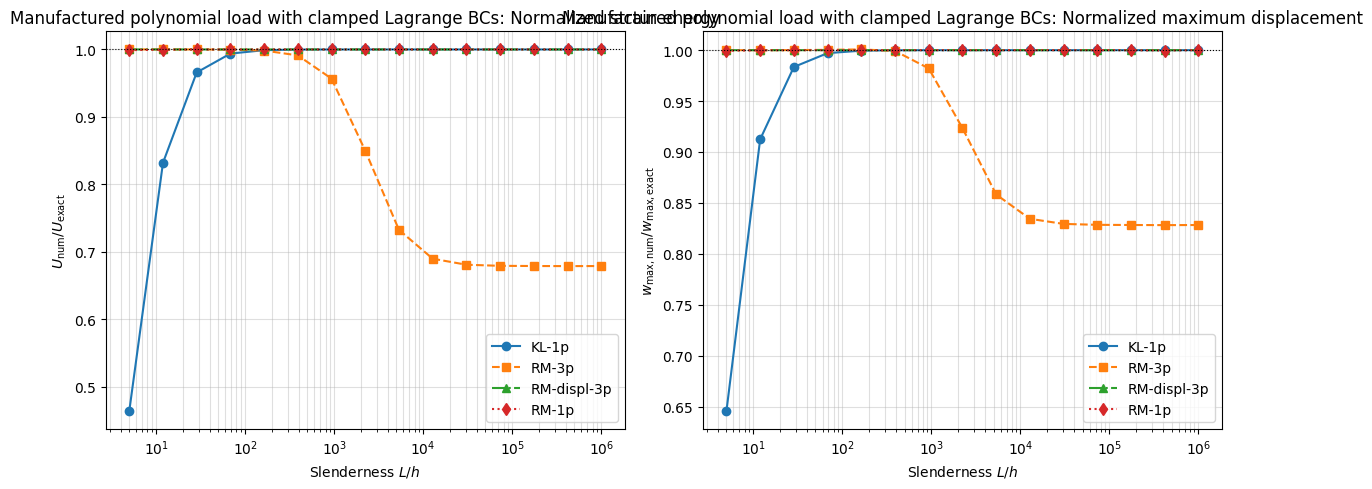

In [8]:
s_history = np.asarray(s_history)
U_exact_history = np.asarray(U_exact_history)
w_exact_history = np.asarray(w_exact_history)

for formulation in FORMULATIONS:
    U_history[formulation] = np.asarray(U_history[formulation])
    w_history[formulation] = np.asarray(w_history[formulation])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

styles = {
    "KL-1p": "o-",
    "RM-3p": "s--",
    "RM-displ-3p": "^-.",
    "RM-1p": "d:",
}

for formulation in FORMULATIONS:
    ax1.plot(
        s_history,
        U_history[formulation] / U_exact_history,
        styles[formulation],
        label=formulation,
    )
ax1.axhline(1.0, color="k", lw=0.8, ls=":")
ax1.set_xscale("log")
ax1.set_xlabel("Slenderness $L/h$")
ax1.set_ylabel(r"$U_\mathrm{num} / U_\mathrm{exact}$")
ax1.set_title("Manufactured polynomial load with clamped Lagrange BCs: Normalized strain energy")
ax1.legend()
ax1.grid(True, which="both", alpha=0.4)

for formulation in FORMULATIONS:
    ax2.plot(
        s_history,
        w_history[formulation] / w_exact_history,
        styles[formulation],
        label=formulation,
    )
ax2.axhline(1.0, color="k", lw=0.8, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel("Slenderness $L/h$")
ax2.set_ylabel(r"$w_{\max,\mathrm{num}} / w_{\max,\mathrm{exact}}$")
ax2.set_title("Manufactured polynomial load with clamped Lagrange BCs: Normalized maximum displacement")
ax2.legend()
ax2.grid(True, which="both", alpha=0.4)

fig.tight_layout()
plt.show()